In [1]:
import platform
import socket

print("Hostname:", socket.gethostname())
print("Machine:", platform.machine())
print("Python:", platform.python_version())

Hostname: pynq
Machine: armv7l
Python: 3.10.4


In [2]:
import pynq

print("PYNQ version:", pynq.__version__)

PYNQ version: 3.1.1


In [7]:
import glob

video_devices = glob.glob("/dev/video*")
print(video_devices)

['/dev/video0', '/dev/video1']


In [8]:
import cv2

for index in [0, 1]:
    camera = cv2.VideoCapture(index)

    print(f"Camera {index}")
    print("  Opened:", camera.isOpened())

    success, frame = camera.read()
    print("  Frame captured:", success)

    if success:
        print("  Shape:", frame.shape)

    camera.release()

[ WARN:0] global ./modules/videoio/src/cap_gstreamer.cpp (616) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


Camera 0
  Opened: True
  Frame captured: True
  Shape: (480, 640, 3)


[ WARN:0] global ./modules/videoio/src/cap_gstreamer.cpp (616) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
[ WARN:0] global ./modules/videoio/src/cap_v4l.cpp (890) open VIDEOIO(V4L2:/dev/video1): can't open camera by index


Camera 1
  Opened: False
  Frame captured: False


In [11]:
import cv2

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)

print("Opened:", camera.isOpened())

success, frame = camera.read()

print("Captured:", success)

if success:
    print("Shape:", frame.shape)

camera.release()

Opened: True
Captured: True
Shape: (480, 640, 3)


In [13]:
import cv2
import matplotlib.pyplot as plt

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)

success, frame = camera.read()

camera.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()
else:
    print("Unable to capture frame")

Unable to capture frame


[ WARN:0] global ./modules/videoio/src/cap_v4l.cpp (890) open VIDEOIO(V4L2:/dev/video0): can't open camera by index


Shape: (480, 640, 3)
Mean brightness: 61.26741861979167


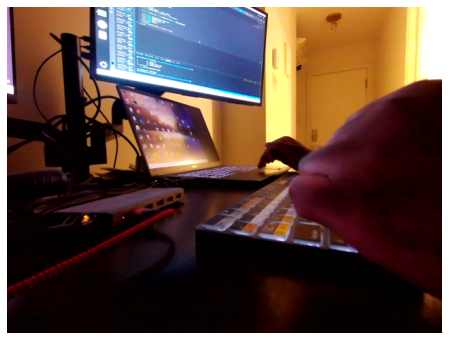

In [15]:
import cv2
import time
import matplotlib.pyplot as plt

camera = cv2.VideoCapture(0, cv2.CAP_V4L2)

if not camera.isOpened():
    print("Unable to open camera")
else:
    # Laisse la caméra initialiser exposition / balance des blancs
    time.sleep(2)

    frame = None
    success = False

    # Jette quelques frames initiales
    for _ in range(10):
        success, frame = camera.read()

    camera.release()

    if success:
        print("Shape:", frame.shape)
        print("Mean brightness:", frame.mean())

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.show()
    else:
        print("Unable to capture frame")

In [ ]:
import cv2
import time
import glob
import matplotlib.pyplot as plt

CAMERA_INDEX = 0

print("OpenCV:", cv2.__version__)
print("Video devices:", glob.glob("/dev/video*"))

camera = cv2.VideoCapture(CAMERA_INDEX, cv2.CAP_V4L2)

if not camera.isOpened():
    raise RuntimeError(f"Unable to open /dev/video{CAMERA_INDEX}")

try:
    # Laisse le temps à la caméra de stabiliser l'exposition.
    time.sleep(2)

    success = False
    frame = None

    # On jette quelques premières frames.
    for _ in range(10):
        success, frame = camera.read()

    if not success or frame is None:
        raise RuntimeError("Unable to capture frame")

    print("Shape:", frame.shape)
    print("Brightness:", frame.mean())
    print("Min:", frame.min())
    print("Max:", frame.max())

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

finally:
    camera.release()

OpenCV: 4.5.4
Video devices: ['/dev/video0', '/dev/video1']
